演習問題1

In [6]:
import pandas as pd
df = pd.read_excel('black_friday.xlsx')
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,2.0,NaN,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,15.0,16.0,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,15.0,NaN,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,NaN,NaN,7172


In [7]:
dataset = df.groupby('User_ID')['Product_ID'].apply(list)
dataset

,Product_ID
User_ID,
1000001,"[P00069042, P00248942, P00087842, P00085442, P..."
1000002,"[P00285442, P00112842, P00293242, P00289342, P..."
1000003,"[P00193542, P00132842, P0098342, P00010242, P0..."
1000004,"[P00184942, P00346142, P0097242, P00046742, P0..."
1000005,"[P00274942, P00251242, P00014542, P00031342, P..."
...,...
1006036,"[P00237642, P00250342, P00173242, P00255342, P..."
1006037,"[P00067342, P00111842, P00323642, P00177442, P..."
1006038,"[P00034742, P00251242, P00086042, P00109542, P..."


In [8]:
!pip install mlxtend==0.23.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.5 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.23.3
    Uninstalling mlxtend-0.23.3:
      Successfully uninstalled mlxtend-0.23.3


In [9]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df2 = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df2, min_support=0.04, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)
frequent_itemsets

,support,itemsets
0,0.315396,(P00265242)
1,0.270073,(P00110742)
2,0.269224,(P00025442)
3,0.261246,(P00112142)
4,0.242743,(P00057642)
...,...,...
4505,0.040061,"(P00052842, P00346242)"
4506,0.040061,"(P00053842, P00145042)"
4507,0.040061,"(P00057542, P00110842)"
4508,0.040061,"(P00057642, P00122442)"


In [10]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric = "lift", min_threshold = 1)
rules = rules.sort_values('support', ascending = False).reset_index(drop=True)

rules

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(P00025442),(P00110742),0.269224,0.270073,0.117637,0.436948,1.617890,0.044927,1.296377,0.522610
1,(P00110742),(P00025442),0.270073,0.269224,0.117637,0.435575,1.617890,0.044927,1.294726,0.523218
2,(P00112142),(P00110742),0.261246,0.270073,0.109998,0.421053,1.559033,0.039443,1.260783,0.485380
3,(P00110742),(P00112142),0.270073,0.261246,0.109998,0.407291,1.559033,0.039443,1.246403,0.491250
4,(P00112142),(P00025442),0.261246,0.269224,0.103887,0.397661,1.477062,0.033554,1.213230,0.437196
...,...,...,...,...,...,...,...,...,...,...
7825,(P00154042),(P00184942),0.104397,0.241725,0.040061,0.383740,1.587508,0.014826,1.230447,0.413221
7826,(P00184942),(P00154042),0.241725,0.104397,0.040061,0.165730,1.587508,0.014826,1.073518,0.488057
7827,(P00044442),(P00157542),0.186556,0.139705,0.040061,0.214741,1.537105,0.013998,1.095556,0.429564
7828,(P00157542),(P00044442),0.139705,0.186556,0.040061,0.286756,1.537105,0.013998,1.140485,0.406170


商品のユニークID「P00025442」と「P00110742」の商品の組み合わせや「P00112142」と「P00110742」の組み合わせでの購入が多い

演習問題2

In [18]:
anime = pd.read_csv('anime_info.csv')
anime

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,anime_id,name,genre,type,episodes,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,151266
...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,211
12290,5543,Under World,Hentai,OVA,1,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,175


In [13]:
ratings = pd.read_csv('anime_ratings.csv')
ratings

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1
...,...,...,...
1042663,9999,19815,9
1042664,9999,22145,10
1042665,9999,22199,9
1042666,9999,23317,10


In [14]:
ratings.describe()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,user_id,anime_id,rating
count,1.042668e+06,1.042668e+06,1.042668e+06
mean,4.997382e+03,8.877528e+03,6.161557e+00
std,2.723698e+03,9.019467e+03,3.701744e+00
min,1.000000e+00,1.000000e+00,-1.000000e+00
25%,2.701000e+03,1.142000e+03,6.000000e+00
50%,5.255000e+03,5.734000e+03,7.000000e+00
75%,7.260000e+03,1.434500e+04,9.000000e+00
max,9.999000e+03,3.432500e+04,1.000000e+01


最大10点、最低-1点、平均6点

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Axes: >

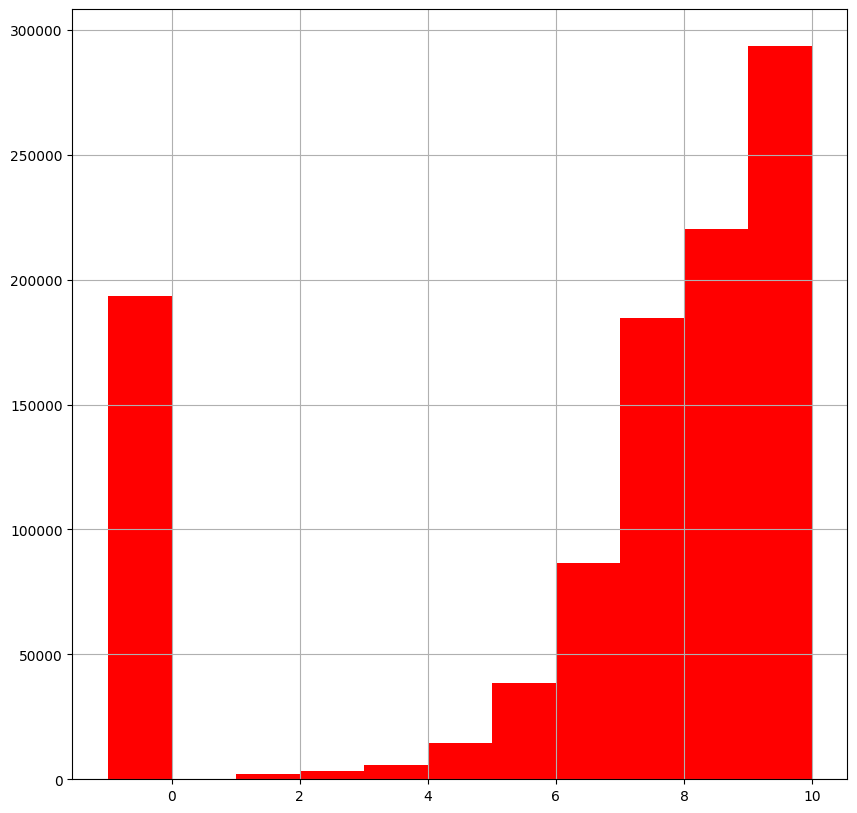

In [15]:
ratings['rating'].hist(bins=11, figsize=(10,10), color = 'red')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Axes: >

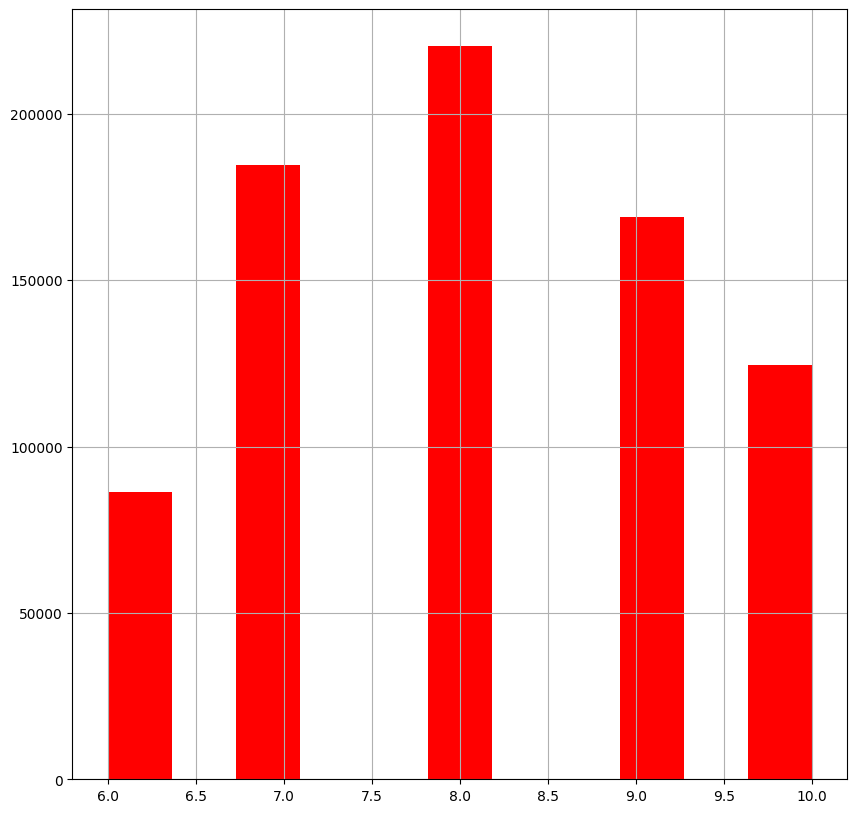

In [16]:
ratings = ratings[ratings.rating >= 6]
ratings['rating'].hist(bins=11, figsize=(10,10), color = 'red')

In [19]:
mergeddf = ratings.merge(anime, on = 'anime_id')
mergeddf

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,user_id,anime_id,rating,name,genre,type,episodes,members
0,1,8074,10,Highschool of the Dead,"Action, Ecchi, Horror, Supernatural",TV,12,535892
1,1,11617,10,High School DxD,"Comedy, Demons, Ecchi, Harem, Romance, School",TV,12,398660
2,1,11757,10,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,25,893100
3,1,15451,10,High School DxD New,"Action, Comedy, Demons, Ecchi, Harem, Romance,...",TV,12,266657
4,2,11771,10,Kuroko no Basket,"Comedy, School, Shounen, Sports",TV,25,338315
...,...,...,...,...,...,...,...,...
785178,9999,19815,9,No Game No Life,"Adventure, Comedy, Ecchi, Fantasy, Game, Super...",TV,12,602291
785179,9999,22145,10,Kuroshitsuji: Book of Circus,"Comedy, Demons, Fantasy, Historical, Shounen, ...",TV,10,122895
785180,9999,22199,9,Akame ga Kill!,"Action, Adventure, Fantasy",TV,24,492133
785181,9999,23317,10,Kuroshitsuji: Book of Murder,"Comedy, Demons, Fantasy, Historical, Mystery, ...",OVA,2,67261


In [20]:
mergeddf = mergeddf[['user_id','name','rating']]
mergeddf

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,user_id,name,rating
0,1,Highschool of the Dead,10
1,1,High School DxD,10
2,1,Sword Art Online,10
3,1,High School DxD New,10
4,2,Kuroko no Basket,10
...,...,...,...
785178,9999,No Game No Life,9
785179,9999,Kuroshitsuji: Book of Circus,10
785180,9999,Akame ga Kill!,9
785181,9999,Kuroshitsuji: Book of Murder,10


In [21]:
mergeddf = mergeddf.drop_duplicates(['user_id','name'])
mergeddf

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,user_id,name,rating
0,1,Highschool of the Dead,10
1,1,High School DxD,10
2,1,Sword Art Online,10
3,1,High School DxD New,10
4,2,Kuroko no Basket,10
...,...,...,...
785178,9999,No Game No Life,9
785179,9999,Kuroshitsuji: Book of Circus,10
785180,9999,Akame ga Kill!,9
785181,9999,Kuroshitsuji: Book of Murder,10


In [22]:
anime_pivot = mergeddf.pivot(index = 'name',columns='user_id',values='rating').fillna(0)
anime_pivot

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


user_id,1,2,3,5,7,8,9,10,11,12,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
name,,,,,,,,,,,,,,,,,,,,,
&quot;Bungaku Shoujo&quot; Kyou no Oyatsu: Hatsukoi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
&quot;Bungaku Shoujo&quot; Memoire,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0
&quot;Bungaku Shoujo&quot; Movie,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
.hack//G.U. Returner,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
.hack//G.U. Trilogy,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
xxxHOLiC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
xxxHOLiC Kei,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
xxxHOLiC Movie: Manatsu no Yoru no Yume,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=9,algorithm= 'brute', metric='cosine')
anime_pivot_sparse = csr_matrix(anime_pivot.values)
model = knn.fit(anime_pivot_sparse)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [28]:
Anime = 'Kimi no Na wa.'

distance, indice = model.kneighbors(anime_pivot.iloc[anime_pivot.index==Anime].values.reshape(1,-1),n_neighbors=11)
for i in range(0, len(distance.flatten())):
  if i == 0:
    print('Recommendations if you like the anime {0}:\n'.format(anime_pivot[anime_pivot.index==Anime].index[0]))
  else:
    print('{0}: {1} with distance {2}'.format(i,anime_pivot.index[indice.flatten()[i]],distance.flatten()[i]))

Recommendations if you like the anime Kimi no Na wa.:

1: Boku dake ga Inai Machi with distance 0.6850264282429654
2: ReLIFE with distance 0.7066747440672698
3: Shigatsu wa Kimi no Uso with distance 0.7170156958612459
4: Re:Zero kara Hajimeru Isekai Seikatsu with distance 0.7313415019538634
5: Kokoro ga Sakebitagatterunda. with distance 0.7352684032410371
6: Orange with distance 0.7435074643319137
7: Hai to Gensou no Grimgar with distance 0.7455640600938749
8: Noragami Aragoto with distance 0.7496892167919438
9: Charlotte with distance 0.7501902629392256
10: One Punch Man with distance 0.7572814311261843


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
